In [1]:

import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

import parameters
import data_handling
from motion_models import MyMotionModel
from particle_filter import (
    Map, State, ParticleFilter, ParticleFilterPlot, find_initial_pose,
)


In [2]:

# Load map and data
map_obj = Map(parameters.wall_corner_list)

filename = './data/robot_data_73_-20_13_03_26_19_01_49.pkl'
pf_data = data_handling.get_file_data_for_pf(filename)

time_list = [row[0] for row in pf_data]
encoder_count_list = [row[2].encoder_counts for row in pf_data]
steering_angle_list = [row[2].steering for row in pf_data]

print(f"Loaded {len(pf_data)} timesteps, "
      f"encoder range [{min(encoder_count_list)}, {max(encoder_count_list)}]")


Loaded 114 timesteps, encoder range [0, 7629]


In [3]:

# Run motion model for comparison trajectory
motion_model = MyMotionModel(
    [0, 0, 0],  # unknown absolute start; use origin
    encoder_count_list[0],
)
x_model, y_model, theta_model = motion_model.traj_propagation(
    time_list, encoder_count_list, steering_angle_list
)


In [4]:

# Helper: run PF and return trajectory + covariance history
import importlib, particle_filter as pf_mod
importlib.reload(pf_mod)
from particle_filter import Map, State, ParticleFilter

map_obj = Map(parameters.wall_corner_list)

def run_pf(initial_state, state_stdev, known_start):
    """Run the particle filter and return (x, y, theta, cov_xy, sigma_theta) lists."""
    pf = ParticleFilter(
        parameters.num_particles,
        map_obj,
        initial_state=initial_state,
        state_stdev=state_stdev,
        known_start_state=known_start,
        encoder_counts_0=pf_data[0][2].encoder_counts,
    )
    x, y, th = [], [], []
    covs, sig_th = [], []

    for t in range(1, len(pf_data)):
        delta_t = pf_data[t][0] - pf_data[t - 1][0]
        row = pf_data[t]
        u_t = np.array([row[2].encoder_counts, row[2].steering])
        z_t = row[2]
        pf.update(u_t, z_t, delta_t)

        m = pf.particle_set.mean_state
        x.append(m.x); y.append(m.y); th.append(m.theta)

        # Weighted covariance from particles
        ps = pf.particle_set
        xs_p = np.array([p.state.x for p in ps.particle_list])
        ys_p = np.array([p.state.y for p in ps.particle_list])
        ths_p = np.array([p.state.theta for p in ps.particle_list])
        ws = np.array([p.weight for p in ps.particle_list], dtype=float)
        ws /= ws.sum() if ws.sum() > 0 else 1.0

        mx, my = np.dot(ws, xs_p), np.dot(ws, ys_p)
        dx, dy = xs_p - mx, ys_p - my
        covs.append(np.array([
            [np.dot(ws, dx * dx), np.dot(ws, dx * dy)],
            [np.dot(ws, dx * dy), np.dot(ws, dy * dy)],
        ]))
        sin_m = np.dot(ws, np.sin(ths_p))
        cos_m = np.dot(ws, np.cos(ths_p))
        R = np.sqrt(sin_m**2 + cos_m**2)
        sig_th.append(np.sqrt(max(-2 * np.log(max(R, 1e-12)), 0)))

    return x, y, th, covs, sig_th

print("run_pf() defined.")


run_pf() defined.


In [5]:

# --- Scenario 1: Good initial guess (from grid search) ---
good_pose = pf_mod.find_initial_pose(map_obj, pf_data[0][2])
print(f"Good pose: ({good_pose.x:.3f}, {good_pose.y:.3f}, {math.degrees(good_pose.theta):.1f}°)")
x_good, y_good, th_good, cov_good, sig_th_good = run_pf(
    good_pose, State(0.3, 0.3, 0.3), known_start=True)
print("Good initial guess done.")

# --- Scenario 2: Bad initial guess (offset from good pose) ---
bad_pose = State(good_pose.x + 1.0, good_pose.y + 1.0, good_pose.theta + math.radians(90))
print(f"Bad pose:  ({bad_pose.x:.3f}, {bad_pose.y:.3f}, {math.degrees(bad_pose.theta):.1f}°)")
x_bad, y_bad, th_bad, cov_bad, sig_th_bad = run_pf(
    bad_pose, State(0.3, 0.3, 0.3), known_start=True)
print("Bad initial guess done.")

# --- Scenario 3: Unknown start (uniform) ---
x_unk, y_unk, th_unk, cov_unk, sig_th_unk = run_pf(
    State(0, 0, 0), State(1, 1, 1), known_start=False)
print("Unknown start done.")


Pre-localization: (0.620, 0.058, 2.0°)  log_w=-1.48
Good pose: (0.620, 0.058, 2.0°)
Known
Good initial guess done.
Bad pose:  (1.620, 1.058, 92.0°)
Known
Bad initial guess done.
Unknown start done.


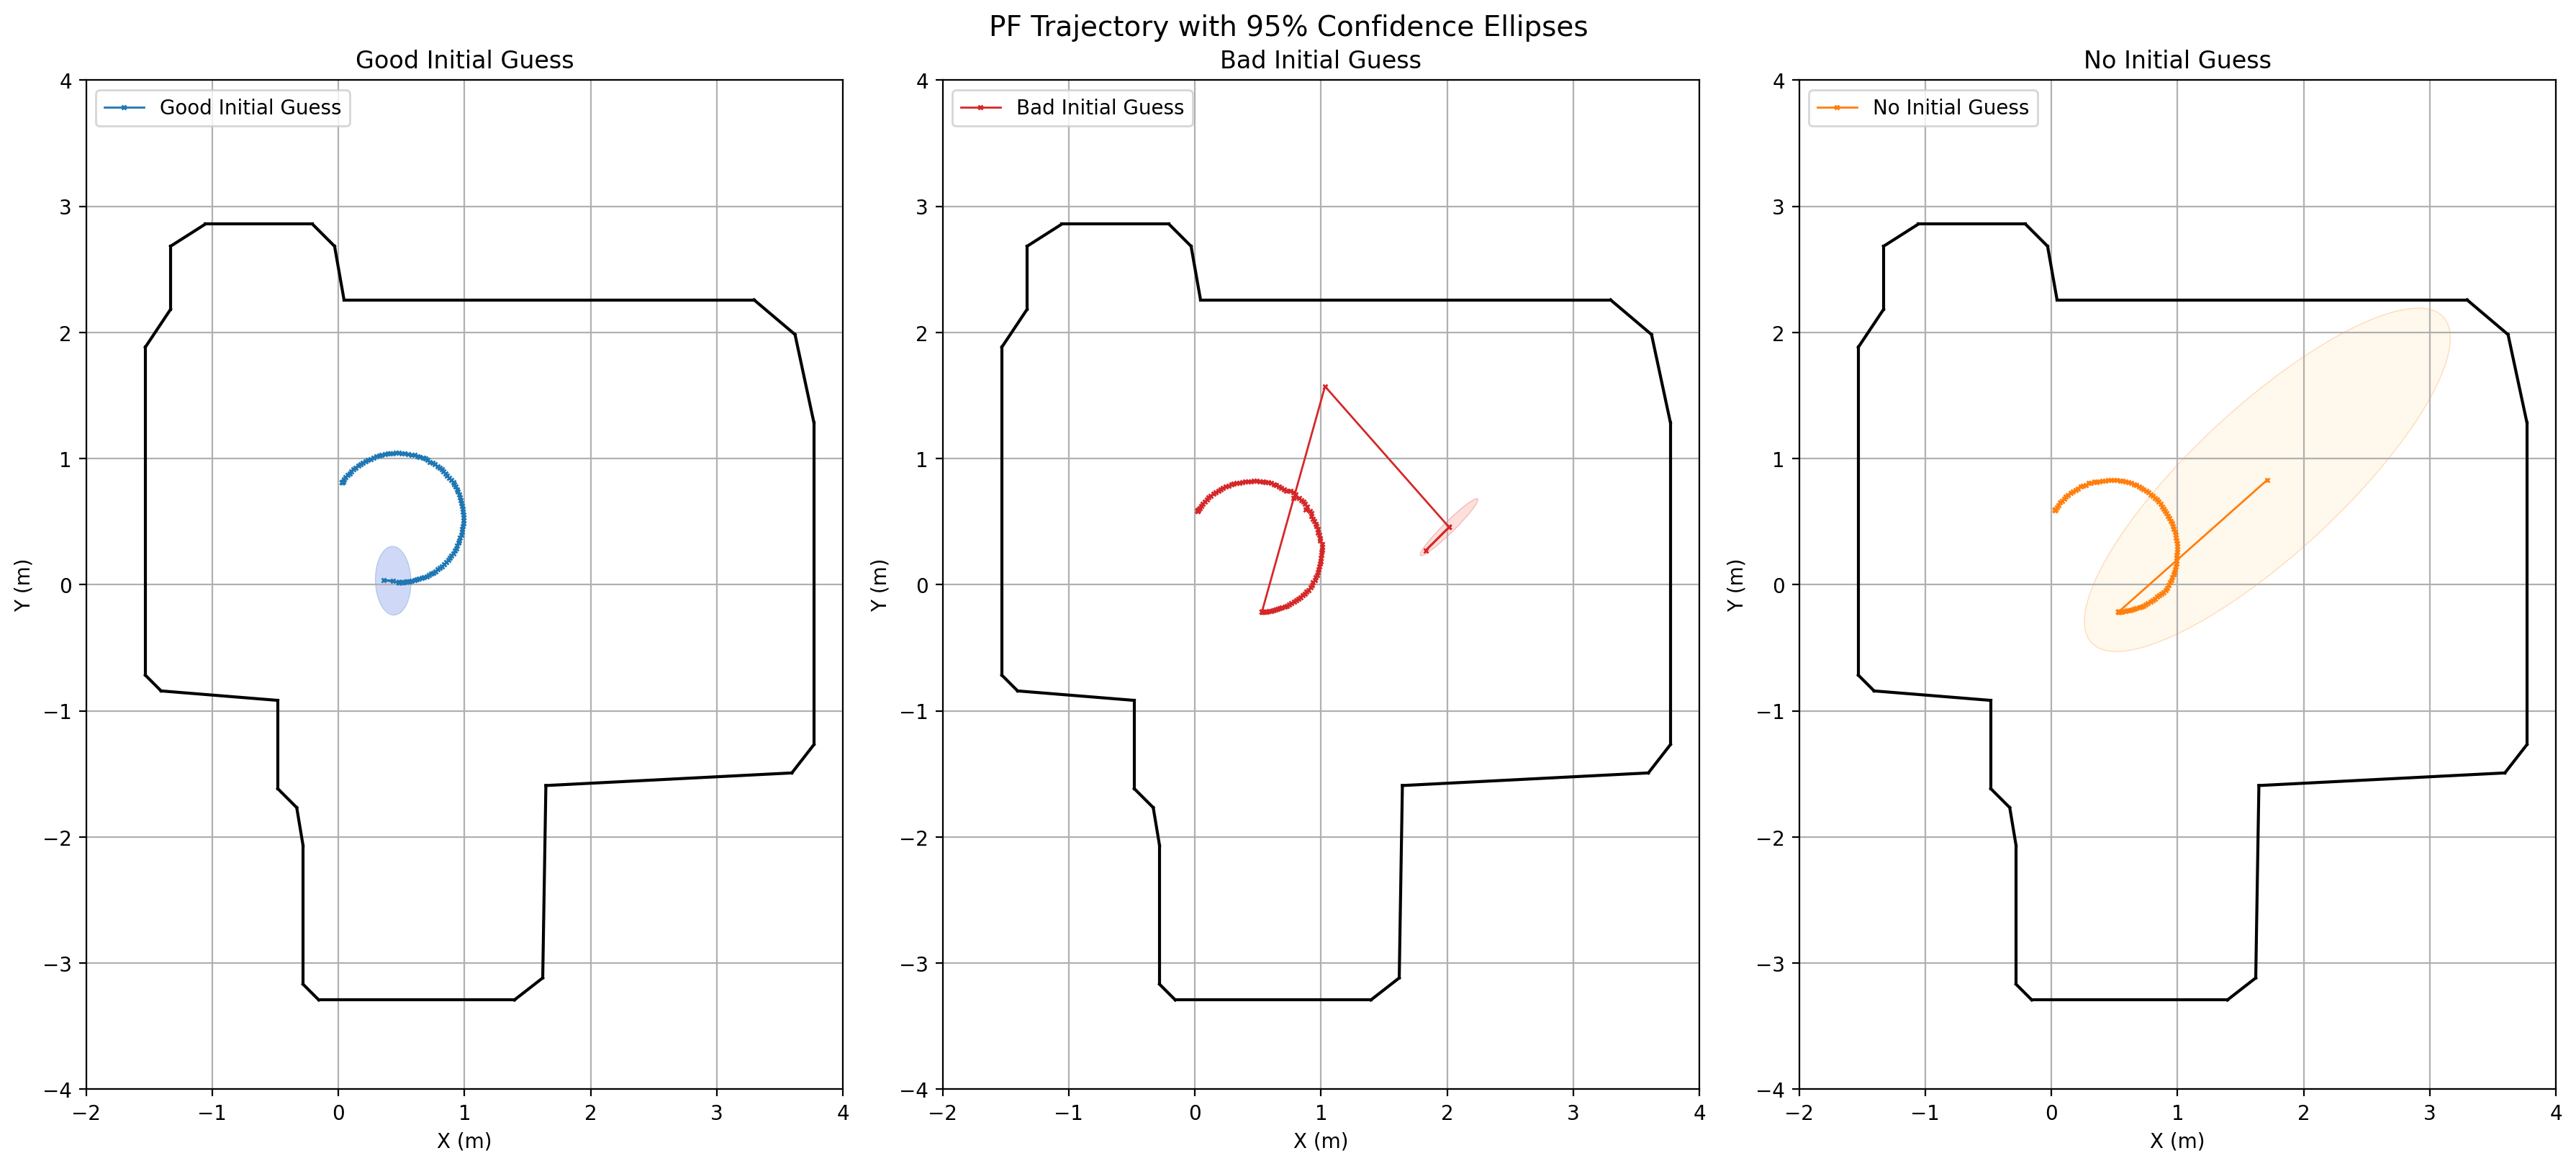

In [6]:

# Plot all three PF trajectories with 95% confidence ellipses
scenarios = [
    ('Good Initial Guess',    x_good, y_good, cov_good, 'tab:blue',   'royalblue'),
    ('Bad Initial Guess',     x_bad,  y_bad,  cov_bad,  'tab:red',    'salmon'),
    ('No Initial Guess', x_unk,  y_unk,  cov_unk,  'tab:orange', 'moccasin'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 8), dpi=200)
N = 10
scale = 5.991  # chi-squared 95% for 2 DOF

for ax, (label, xs, ys, covs, color, ell_color) in zip(axes, scenarios):
    # Map walls
    for wall in map_obj.wall_list:
        ax.plot([wall.corner1.x, wall.corner2.x],
                [wall.corner1.y, wall.corner2.y], 'k-', linewidth=1.5)

    # Trajectory
    ax.plot(xs, ys, label=label, marker='x', markersize=2,
            linestyle='-', linewidth=1, color=color)

    # Confidence ellipses
    for i in range(0, len(covs), N):
        eigvals, eigvecs = np.linalg.eigh(covs[i])
        eigvals = np.maximum(eigvals, 0)
        w = 2 * np.sqrt(scale * eigvals[0])
        h = 2 * np.sqrt(scale * eigvals[1])
        ang = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
        ell = Ellipse(xy=(xs[i], ys[i]), width=w, height=h, angle=ang,
                      facecolor=ell_color, edgecolor=color, alpha=0.25, linewidth=0.5)
        ax.add_patch(ell)

    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_title(label)
    ax.legend(loc='upper left')
    ax.set_aspect('equal')
    ax.set_xlim(-2, 4)
    ax.set_ylim(-4, 4)
    ax.grid()

fig.suptitle('PF Trajectory with 95% Confidence Ellipses', fontsize=14)
plt.tight_layout()
plt.show()


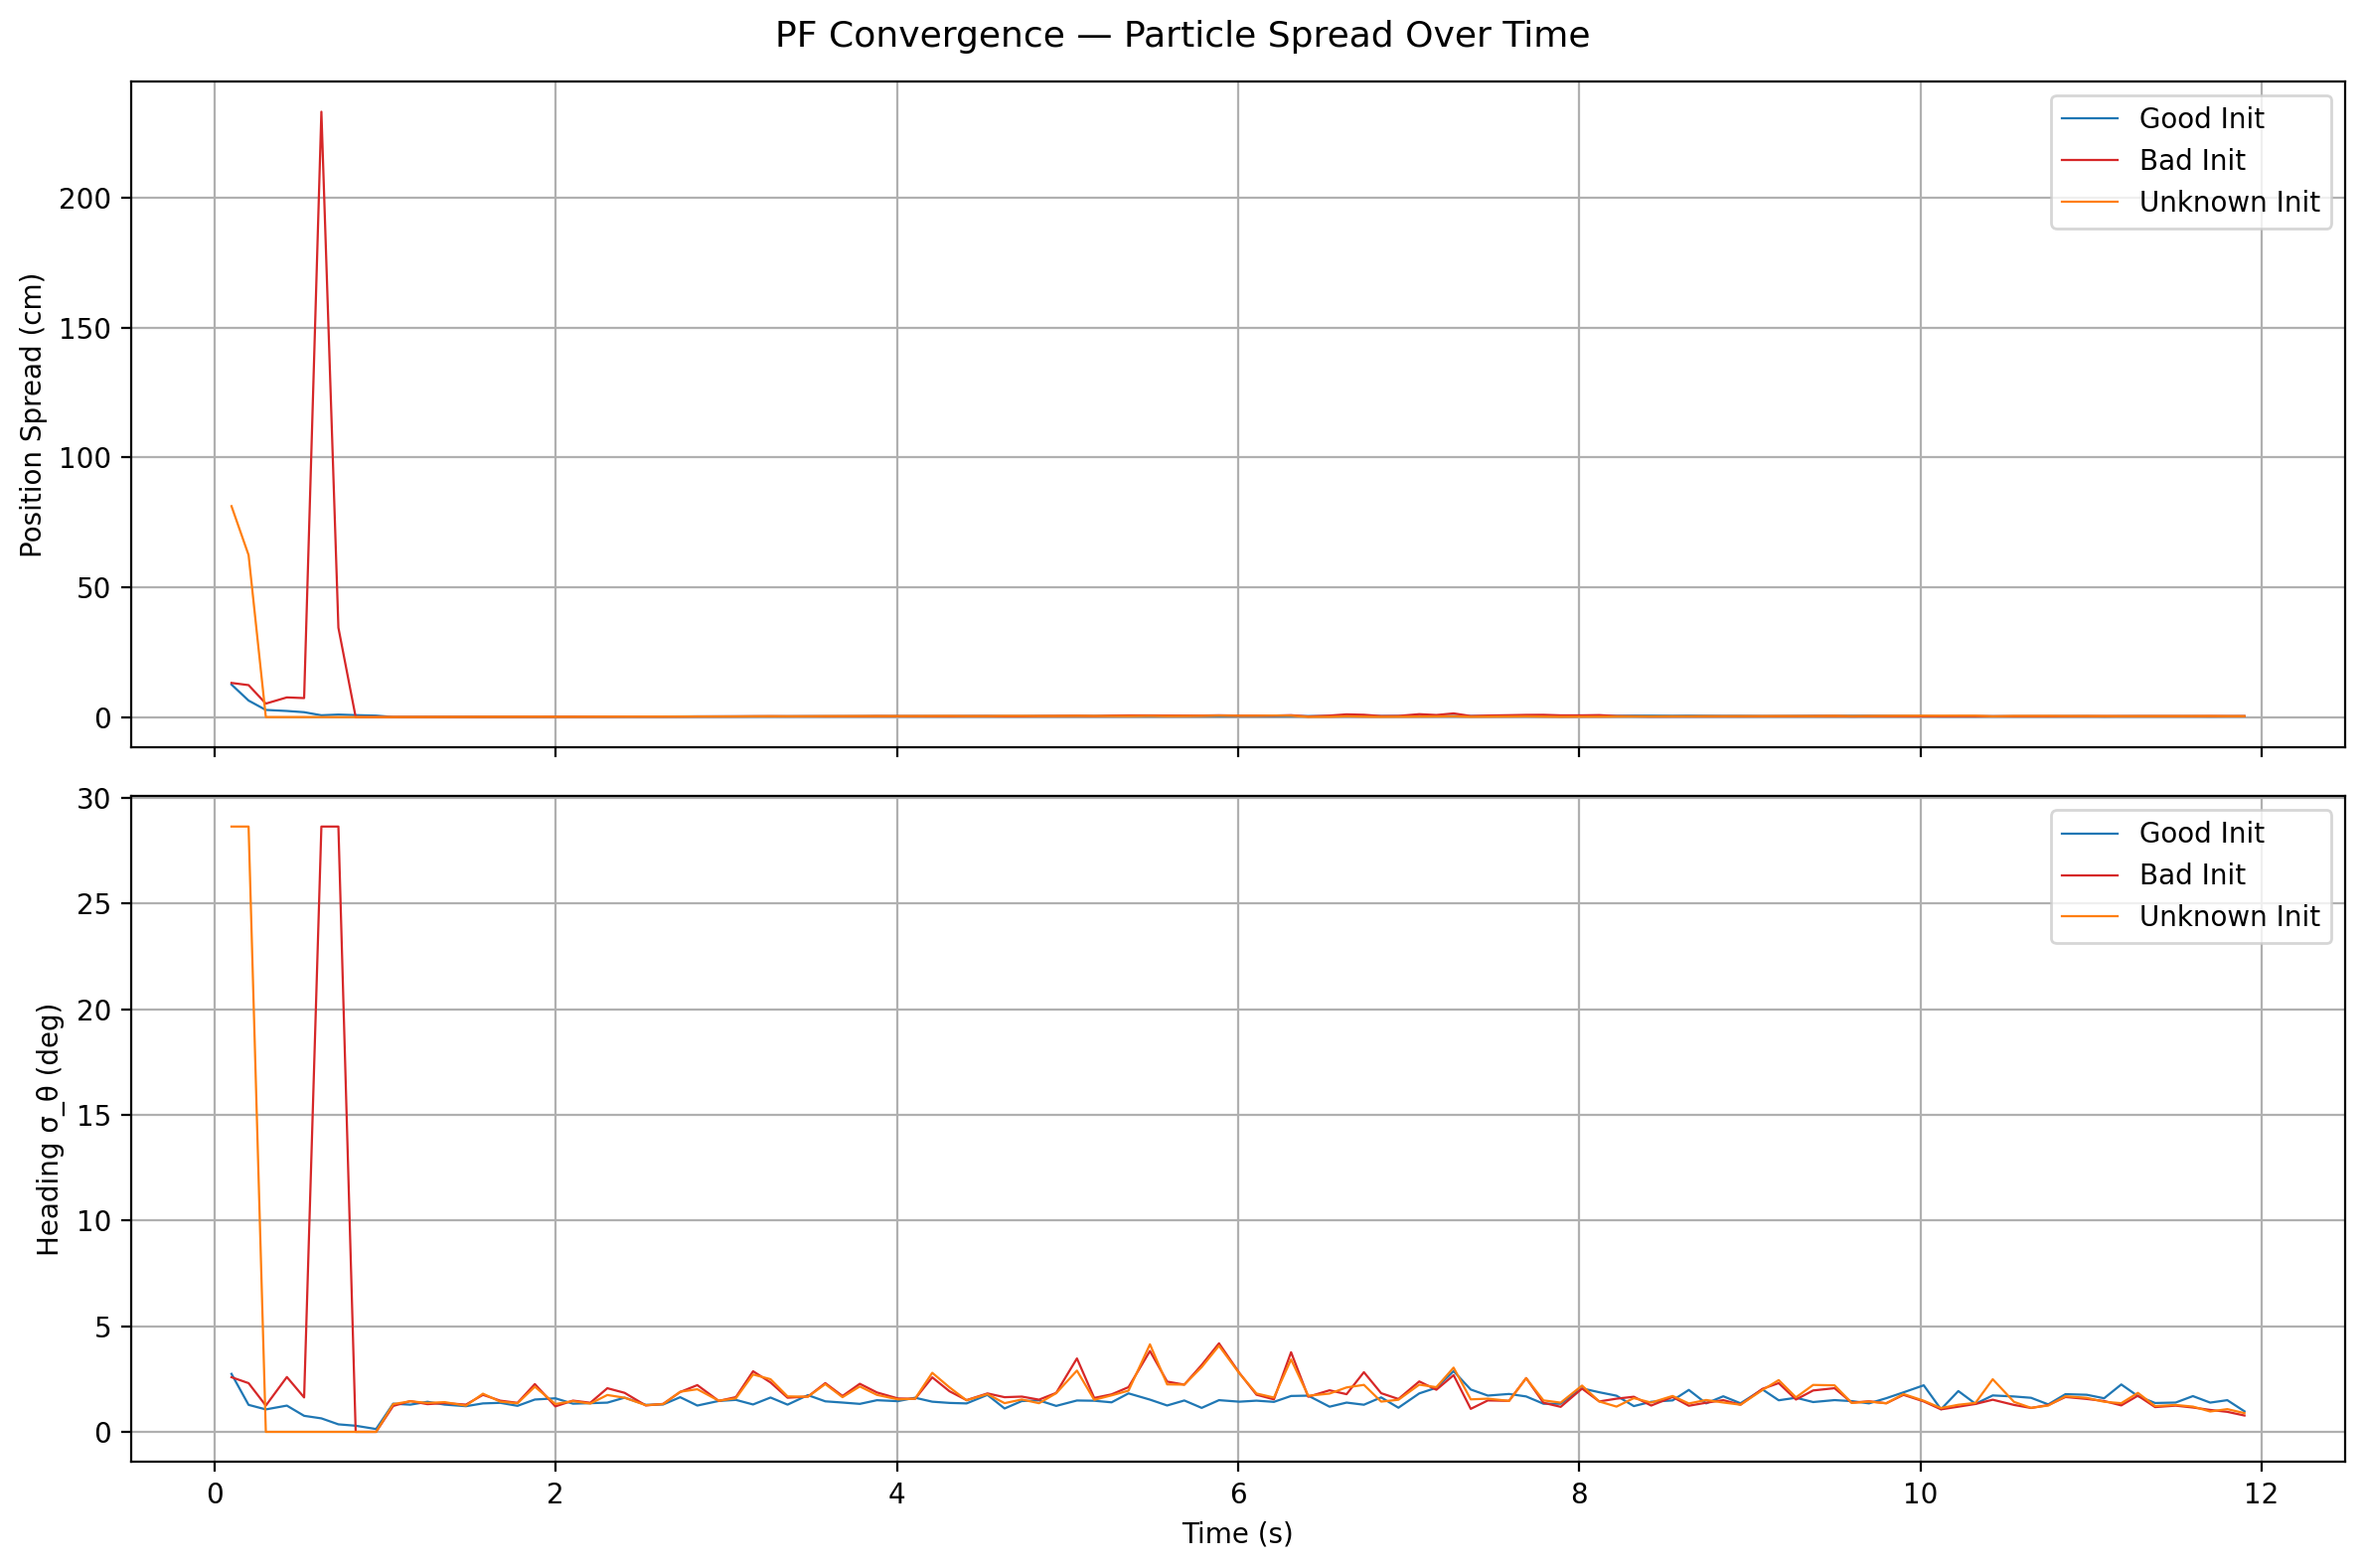

Good Init       final: (0.030, 0.812, -122.5°)  spread=0.29 cm  σ_θ=0.97°
Bad Init        final: (0.021, 0.588, -120.5°)  spread=0.33 cm  σ_θ=0.77°
Unknown Init    final: (0.027, 0.593, -120.5°)  spread=0.34 cm  σ_θ=0.89°


In [ ]:

# Convergence comparison: position spread and heading uncertainty over time
time_pf = np.array(time_list[1:])

conv_scenarios = [
    ('Good Init',    cov_good, sig_th_good, 'tab:blue'),
    ('Bad Init',     cov_bad,  sig_th_bad,  'tab:red'),
    ('Unknown Init', cov_unk,  sig_th_unk,  'tab:orange'),
]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, dpi=200)

for label, covs, sig_ths, color in conv_scenarios:
    pos_spread = np.array([np.sqrt(np.trace(c)) for c in covs])
    axes[0].plot(time_pf, pos_spread * 100, linewidth=0.8, color=color, label=label)
    axes[1].plot(time_pf, np.degrees(np.minimum(np.array(sig_ths), 0.5)),
                 linewidth=0.8, color=color, label=label)

axes[0].set_ylabel('Position Spread (cm)')
axes[0].legend()
axes[0].grid()

axes[1].set_ylabel('Heading sigma_θ (deg)')
axes[1].set_xlabel('Time (s)')
axes[1].legend()
axes[1].grid()

fig.suptitle('PF Convergence — Particle Spread Over Time', fontsize=13)
plt.tight_layout()
plt.show()

# Print final estimates for each scenario
for label, xs, ys, ths, covs, sig_ths in [
    ('Good Init',    x_good, y_good, th_good, cov_good, sig_th_good),
    ('Bad Init',     x_bad,  y_bad,  th_bad,  cov_bad,  sig_th_bad),
    ('Unknown Init', x_unk,  y_unk,  th_unk,  cov_unk,  sig_th_unk),
]:
    spread = np.sqrt(np.trace(covs[-1])) * 100
    print(f"{label:14s}  final: ({xs[-1]:.3f}, {ys[-1]:.3f}, {math.degrees(ths[-1]):.1f}°)"
          f"  spread={spread:.2f} cm  sigma_θ={math.degrees(sig_ths[-1]):.2f}°")


In [ ]:

# ── Performance Metrics ──────────────────────────────────────────────────────
# Since there is no ground-truth trajectory, we evaluate the PF using
# self-consistency metrics derived from the particle distribution itself.

all_scenarios = [
    ('Good Init',    x_good, y_good, th_good, cov_good, sig_th_good, 'tab:blue'),
    ('Bad Init',     x_bad,  y_bad,  th_bad,  cov_bad,  sig_th_bad,  'tab:red'),
    ('Unknown Init', x_unk,  y_unk,  th_unk,  cov_unk,  sig_th_unk,  'tab:orange'),
]

print("=" * 90)
print(f"{'Metric':<32s}  {'Good Init':>16s}  {'Bad Init':>16s}  {'Unknown Init':>16s}")
print("=" * 90)

rows = {}
for label, xs, ys, ths, covs, sig_ths, _ in all_scenarios:
    pos_spread = np.array([np.sqrt(np.trace(c)) for c in covs])
    sig_th_arr = np.array(sig_ths)

    # --- Final-state spread ---
    final_spread_cm = pos_spread[-1] * 100
    final_sig_th_deg = math.degrees(sig_th_arr[-1])

    # --- Mean spread over entire run ---
    mean_spread_cm = np.mean(pos_spread) * 100
    mean_sig_th_deg = np.mean(np.degrees(sig_th_arr))

    # --- Convergence time: first time position spread drops below 20 cm and stays ---
    threshold_m = 0.20
    converged_idx = None
    for i in range(len(pos_spread)):
        if np.all(pos_spread[i:] < threshold_m):
            converged_idx = i
            break
    if converged_idx is not None:
        conv_time = float(time_pf[converged_idx] - time_pf[0])
    else:
        conv_time = None

    # --- Trajectory smoothness: mean step-to-step displacement jitter ---
    dx = np.diff(xs)
    dy = np.diff(ys)
    step_dist = np.sqrt(dx**2 + dy**2)
    smoothness = float(np.std(step_dist)) * 100  # cm

    # --- Maximum single-step jump (teleportation indicator) ---
    max_jump_cm = float(np.max(step_dist)) * 100

    # --- 95% confidence area (mean ellipse area over run) ---
    areas = []
    for c in covs:
        eigvals = np.linalg.eigvalsh(c)
        eigvals = np.maximum(eigvals, 0)
        areas.append(math.pi * 2 * math.sqrt(5.991) ** 2
                     * math.sqrt(eigvals[0]) * math.sqrt(eigvals[1]))
    mean_area = np.mean(areas)

    rows[label] = {
        'Final pos spread (cm)':      f"{final_spread_cm:.2f}",
        'Final heading sigma_θ (deg)':    f"{final_sig_th_deg:.2f}",
        'Mean pos spread (cm)':       f"{mean_spread_cm:.2f}",
        'Mean heading sigma_θ (deg)':     f"{mean_sig_th_deg:.2f}",
        'Convergence time (s)':       f"{conv_time:.2f}" if conv_time is not None else "never",
        'Step jitter sigma (cm)':         f"{smoothness:.2f}",
        'Max single-step jump (cm)':  f"{max_jump_cm:.2f}",
        'Mean 95% ellipse area (m²)': f"{mean_area:.4f}",
    }

for metric in rows['Good Init']:
    vals = [rows[label][metric] for label, *_ in all_scenarios]
    print(f"{metric:<32s}  {vals[0]:>16s}  {vals[1]:>16s}  {vals[2]:>16s}")

print("=" * 90)


Metric                                   Good Init          Bad Init      Unknown Init
Final pos spread (cm)                         0.29              0.33              0.34
Final heading σ_θ (deg)                       0.97              0.77              0.89
Mean pos spread (cm)                          0.54              3.11              1.55
Mean heading σ_θ (deg)                        1.48              5.91              3.29
Convergence time (s)                          0.00              0.73              0.20
Step jitter σ (cm)                            1.27             22.20             14.69
Max single-step jump (cm)                    11.86            185.78            157.94
Mean 95% ellipse area (m²)                  0.0030            0.9152            0.0621


In [ ]:

# Compact metrics summary for report
for label in ['Good Init', 'Bad Init', 'Unknown Init']:
    r = rows[label]
    print(f"{label}: spread={r['Final pos spread (cm)']}cm, sig_th={r['Final heading sigma_θ (deg)']}°, "
          f"conv={r['Convergence time (s)']}s, jitter={r['Step jitter sigma (cm)']}cm, "
          f"max_jump={r['Max single-step jump (cm)']}cm, area={r['Mean 95% ellipse area (m²)']}m², "
          f"mean_spread={r['Mean pos spread (cm)']}cm, mean_sig_th={r['Mean heading sigma_θ (deg)']}°")


Good Init: spread=0.29cm, sig_th=0.97°, conv=0.00s, jitter=1.27cm, max_jump=11.86cm, area=0.0030m², mean_spread=0.54cm, mean_sig_th=1.48°
Bad Init: spread=0.33cm, sig_th=0.77°, conv=0.73s, jitter=22.20cm, max_jump=185.78cm, area=0.9152m², mean_spread=3.11cm, mean_sig_th=5.91°
Unknown Init: spread=0.34cm, sig_th=0.89°, conv=0.20s, jitter=14.69cm, max_jump=157.94cm, area=0.0621m², mean_spread=1.55cm, mean_sig_th=3.29°
